# NLP Basics with NLTK — Optimized
From tokenization to word clouds. Industry-standard conventions, with the demo-code bugs fixed (POS-aware lemmatization, full-sentence tagging, etc.).

**Author:** Manglam · **Mentor review:** Claude Guruji

## 0. Imports

In [1]:
import nltk
from nltk.tokenize import word_tokenize, sent_tokenize, wordpunct_tokenize
from nltk.util import ngrams
from nltk.stem import PorterStemmer, SnowballStemmer, WordNetLemmatizer
from nltk.corpus import stopwords, wordnet
from nltk import pos_tag, ne_chunk

from wordcloud import WordCloud
import matplotlib.pyplot as plt

## 1. One-time data download
These are the **data packs** (fuel), not the library. Run once, then comment out.

In [2]:
for pkg in ['punkt', 'punkt_tab', 'wordnet', 'omw-1.4', 'stopwords',
            'averaged_perceptron_tagger_eng', 'maxent_ne_chunker_tab', 'words']:
    nltk.download(pkg, quiet=True)

## 2. Sample text

In [3]:
AI = '''Artificial Intelligence refers to the intelligence of machines. This is in contrast to the natural intelligence of humans and animals. With Artificial Intelligence, machines perform functions such as learning, planning, reasoning and problem-solving.'''
type(AI)

str

## 3. Tokenization
- `word_tokenize` -> words + punctuation as separate tokens
- `sent_tokenize` -> smart sentence split (won't break `$3.88`)
- `wordpunct_tokenize` -> most aggressive, splits every punctuation

In [4]:
AI_tokens = word_tokenize(AI)
AI_sent   = sent_tokenize(AI)
AI_punct  = wordpunct_tokenize(AI)

print('word tokens :', len(AI_tokens))
print('sentences   :', len(AI_sent))
print('wordpunct   :', len(AI_punct))

word tokens : 39
sentences   : 3
wordpunct   : 41


## 4. N-grams (capture word order)
Count of n-grams = **N - n + 1**. `bigrams`=2, `trigrams`=3.

In [5]:
bigrams  = list(ngrams(AI_tokens, 2))
trigrams = list(ngrams(AI_tokens, 3))
print('bigrams :', len(bigrams), '->', bigrams[:3])
print('trigrams:', len(trigrams), '->', trigrams[:3])

bigrams : 38 -> [('Artificial', 'Intelligence'), ('Intelligence', 'refers'), ('refers', 'to')]
trigrams: 37 -> [('Artificial', 'Intelligence', 'refers'), ('Intelligence', 'refers', 'to'), ('refers', 'to', 'the')]


## 5. Stemming vs Lemmatization
- **Stemming** = blind suffix chop (fast, may produce non-words)
- **Lemmatization** = dictionary lookup (accurate, real words, **needs POS**)

Helper maps Penn-Treebank tags -> WordNet tags so lemmatization is POS-aware.

In [6]:
def wordnet_pos(treebank_tag):
    if treebank_tag.startswith('J'):
        return wordnet.ADJ
    if treebank_tag.startswith('V'):
        return wordnet.VERB
    if treebank_tag.startswith('R'):
        return wordnet.ADV
    return wordnet.NOUN  # sensible default

stemmer    = SnowballStemmer('english')   # improved Porter + multilingual
lemmatizer = WordNetLemmatizer()

words = ['give', 'giving', 'given', 'gave', 'thinking', 'loving', 'studies']
tagged = pos_tag([w.lower() for w in words])   # lowercase first!

print('stems :', [stemmer.stem(w) for w, _ in tagged])
print('lemmas:', [lemmatizer.lemmatize(w, wordnet_pos(t)) for w, t in tagged])

stems : ['give', 'give', 'given', 'gave', 'think', 'love', 'studi']
lemmas: ['give', 'give', 'give', 'give', 'think', 'loving', 'study']


## 6. Stopword removal
Drop low-meaning filler words (`the`, `is`, `of`...). `set()` for fast lookups.

In [7]:
sw = set(stopwords.words('english'))
cleaned = [w for w in AI_tokens if w.lower() not in sw and w.isalpha()]
print('English stopwords:', len(sw))
print('cleaned tokens   :', cleaned[:10], '...')

English stopwords: 198
cleaned tokens   : ['Artificial', 'Intelligence', 'refers', 'intelligence', 'machines', 'contrast', 'natural', 'intelligence', 'humans', 'animals'] ...


## 7. POS tagging
**Tag the whole sentence at once** - context matters (`book` = noun or verb).

In [8]:
sentence = 'My name is Manglam and I study data science'
print(pos_tag(word_tokenize(sentence)))

[('My', 'PRP$'), ('name', 'NN'), ('is', 'VBZ'), ('Manglam', 'NNP'), ('and', 'CC'), ('I', 'PRP'), ('study', 'VBP'), ('data', 'NNS'), ('science', 'NN')]


## 8. Named Entity Recognition (NER)
Pipeline: `word_tokenize` -> `pos_tag` -> `ne_chunk`. Labels: PERSON, ORGANIZATION, GPE, LOCATION.

In [9]:
NE_sent = 'The capital of India is New Delhi'
tree = ne_chunk(pos_tag(word_tokenize(NE_sent)))
entities = [(' '.join(tok for tok, _ in st.leaves()), st.label())
            for st in tree if hasattr(st, 'label')]
print('entities:', entities)

entities: [('India', 'GPE'), ('New Delhi', 'GPE')]


## 9. Word cloud
Font size = word frequency. `mode='RGBA'` enables transparency, `interpolation='bilinear'` smooths edges, `axis('off')` hides ticks, `margins(0,0)` trims padding.

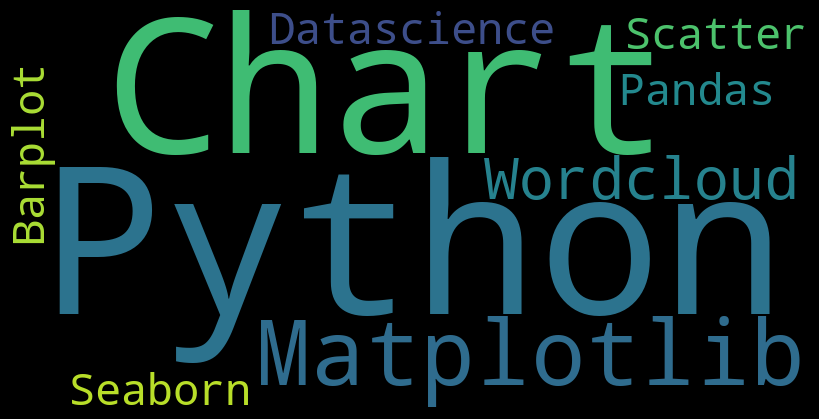

In [10]:
text = ('Python Python Python Matplotlib Matplotlib Seaborn Chart Chart Chart '
        'Pandas Datascience Wordcloud Wordcloud Scatter Barplot')

wc = WordCloud(width=800, height=400, margin=2, background_color='black',
               colormap='viridis', mode='RGBA').generate(text)

plt.figure(figsize=(8, 4))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.margins(x=0, y=0)
plt.tight_layout(pad=0)
plt.show()